In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import matplotlib.pyplot as plt
import mudata
import celldega as dega
import scanpy as sc
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import warnings
warnings.filterwarnings("ignore")



env: ANYWIDGET_HMR=1


In [ ]:
# dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs'
tech = 'Xenium'
DATA_DIR = f'data/raw'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'data/landscape_files/{dataset_name}'

# Load h5ad file
adata = sc.read_h5ad(f'{data_dir}.h5ad')
adata.obs.set_index('cell_id', inplace=True)

gdf_trx = dega.nbhd._get_gdf_trx(data_dir)
gdf_cell = dega.nbhd._get_gdf_cell(adata)
df_cell = dega.nbhd._get_df_cell(adata)


In [4]:
# mdata = mudata.MuData({'ALPH': adata_alph, 'HEX': adata_hex, 'GRAD': adata_grad})
# mdata.write(f"{path_landscape_files}/nhbd_collections.h5mu")  

# import muon as mu

# # Load the h5mu file
# mdata = mu.read(f"{path_landscape_files}/nhbd_collections.h5mu")

## Create gdf for all types of nbhd

In [3]:
# ALPHA
alphas_list = range(30, 60, 5)
gdf_alpha = dega.nbhd.alpha_shape_cell_clusters(df_cell, cat='cluster', alphas=alphas_list)
gdf_alpha_select = gdf_alpha.loc[gdf_alpha['inv_alpha']==35]

# Hex
gdf_hex = dega.nbhd.generate_hex_grid(gdf_cell, radius=50)

# SKTCH
gdf_micron = gpd.read_parquet(f'{path_landscape_files}/spatial_regions/sketched_regions_micron.parquet')
gdf_micron['name'] = gdf_micron['roi']

# GRAD
gdf_roi = gdf_micron.loc[gdf_micron['roi'] == 'region_1']
gdf_bands = dega.nbhd.calc_grad_nbhd_from_roi(gdf_roi, gdf_cell, 200)
gdf_bands['name'] = gdf_bands['band']

nbhd_lookup = {
    'ALPH': gdf_alpha_select,
    'HEX': gdf_hex,
    'SKTCH': gdf_micron,
    'GRAD': gdf_bands,
}


In [4]:
nbhd_type = 'HEX'  # Choose from 'ALPH', 'HEX', 'SKTCH', 'GRAD'

## Create NBHD instance

In [5]:
# Create NBHD instance
nbhd = dega.nbhd.NBHD(nbhd_lookup[nbhd_type], nbhd_type=nbhd_type, source='X cells', name='X cell alpha shapes')

# Calculate derived gene expression NBG-CD, NBG-LCD
nbg_dict_cd = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'CD', 'name')
nbg_dict_lcd = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'LCD', 'name')

# Calculate derived gene expression NBG-CF
cbg_cf= dega.nbhd.calc_nbg_cf(data_dir, nbhd_lookup[nbhd_type], unique_nbhd_col='name')

# Attach derived neighborhood gene expression
nbhd.set_derived('NBG-CD', nbg_dict_cd)
nbhd.set_derived('NBG-CF', cbg_cf)

# Add cluster-specific gene expression
for cluster in nbg_dict_lcd.keys():
    if cluster != 'all':
        nbhd.set_derived('NBG-LCD', nbg_dict_lcd[cluster], subkey=cluster)

# Calculate derived NBP
gdf_nbp, gdf_nbp_pct = dega.nbhd.calc_nbp(gdf_cell, nbhd_lookup[nbhd_type])

# Attach derived NBP
nbhd.set_derived('NBP', gdf_nbp, subkey='abs')
nbhd.set_derived('NBP', gdf_nbp_pct, subkey='pct')


## Retrieve data and plot

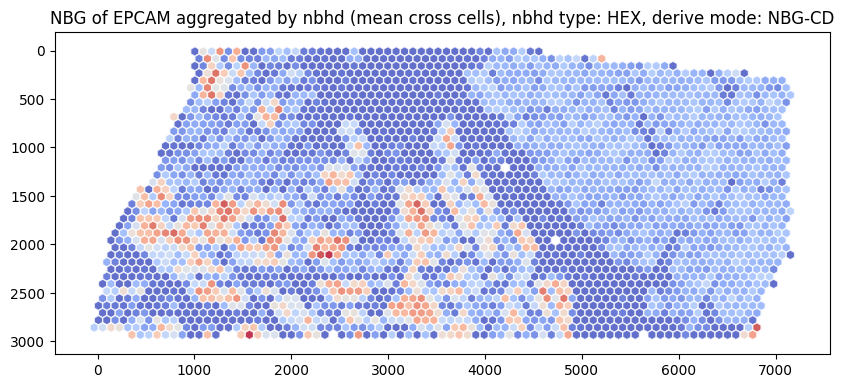

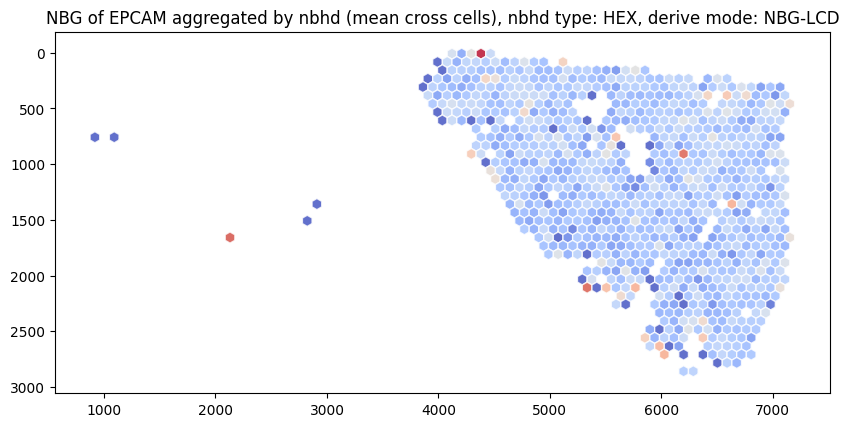

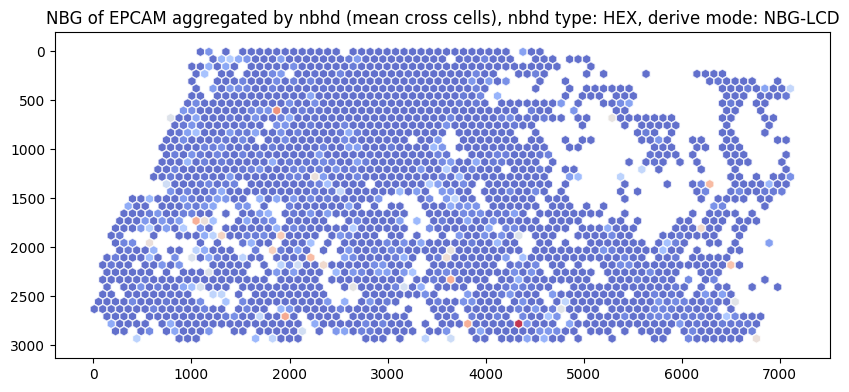

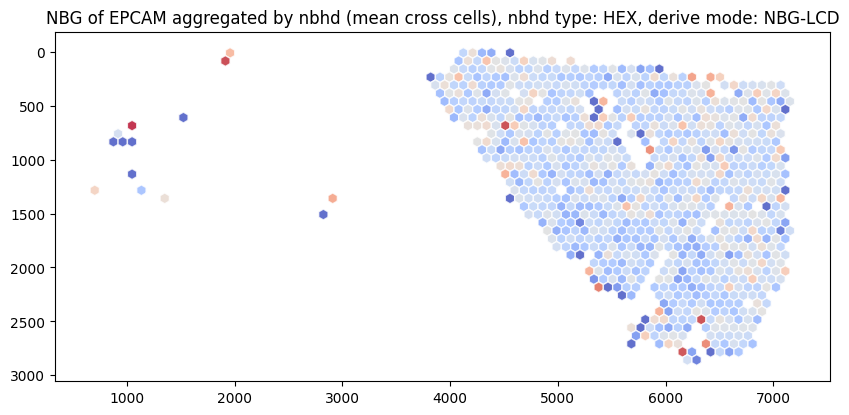

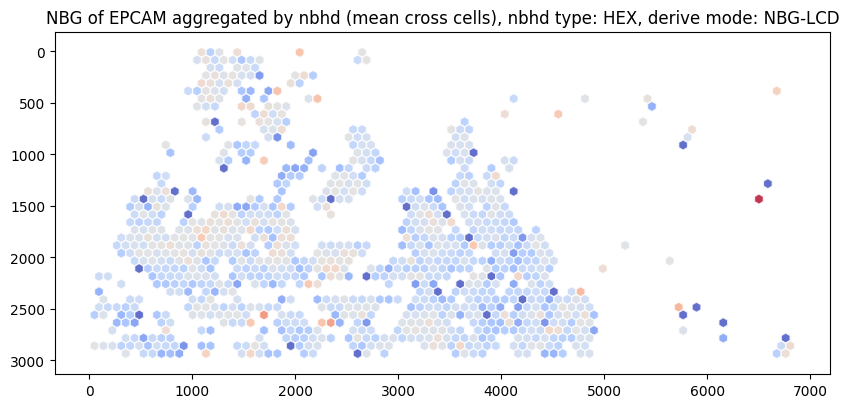

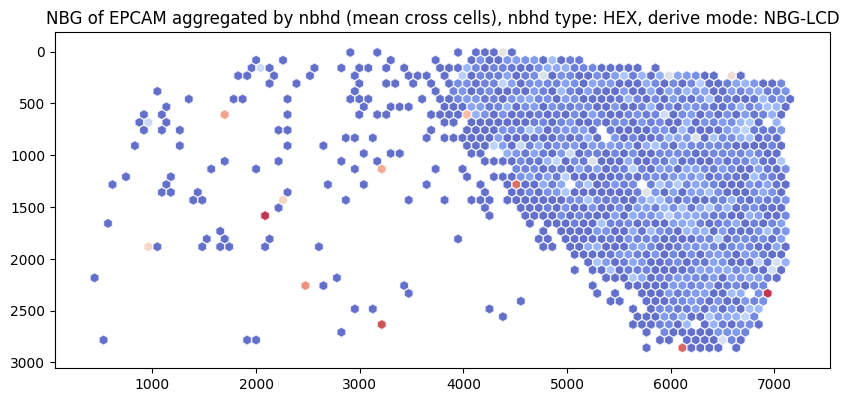

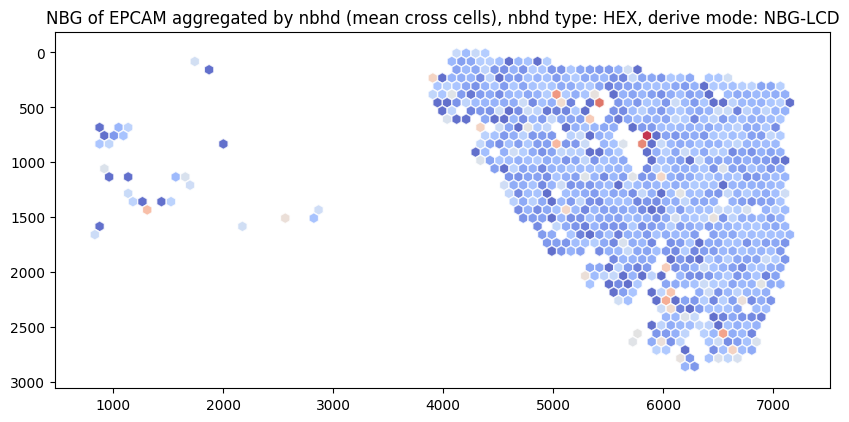

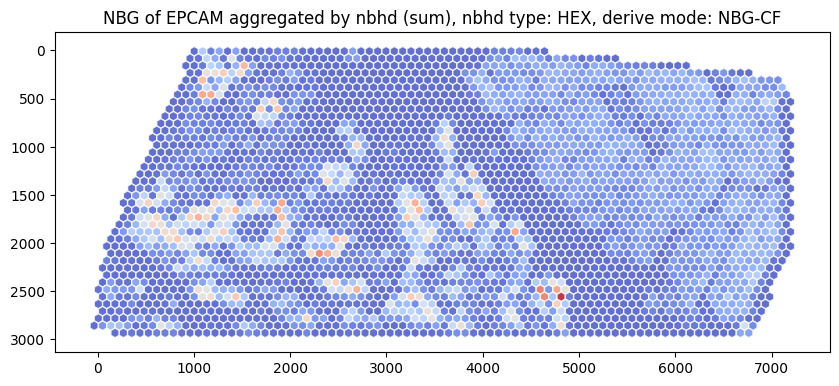

In [6]:
gene = 'EPCAM'

# Retrieve and visualize
gdf_nbg_cd = nbhd.get_derived('NBG-CD')

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} aggregated by nbhd (mean cross cells), nbhd type: {nbhd_type}, derive mode: NBG-CD')
ax.invert_yaxis()
plt.show()

# Retrieve and visualize
clusters = ['1','2','3', '4','5','6']
for cluster in clusters:
    gdf_nbg_lcd = nbhd.get_derived('NBG-LCD', cluster)
    fig, ax = plt.subplots(figsize=(10, 5))                           
    gdf_nbg_lcd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'NBG of {gene} aggregated by nbhd (mean cross cells), nbhd type: {nbhd_type}, derive mode: NBG-LCD')       
    ax.invert_yaxis()
    plt.show()

# Retrieve and visualize
gdf_nbg_cf = nbhd.get_derived('NBG-CF')

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cf.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} aggregated by nbhd (sum), nbhd type: {nbhd_type}, derive mode: NBG-CF')
ax.invert_yaxis()
plt.show()


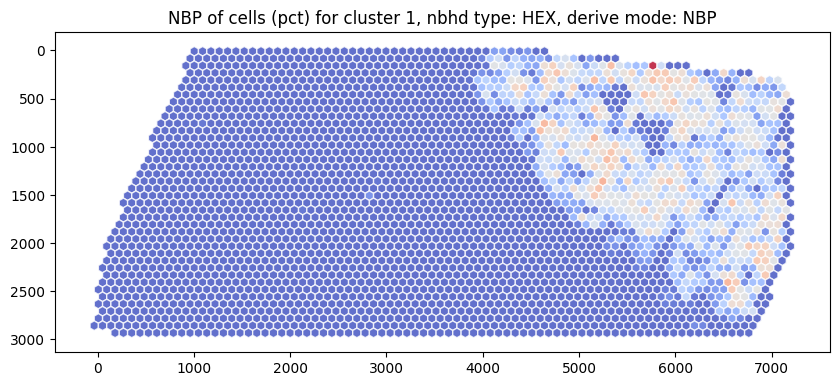

In [7]:
# Retrieve and visualize
sub_key = 'pct'
cluster_name = '1'

gdf_nbp = nbhd.get_derived('NBP', sub_key)

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbp.plot(cluster_name, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBP of cells ({sub_key}) for cluster {cluster_name}, nbhd type: {nbhd_type}, derive mode: NBP')
ax.invert_yaxis()
plt.show()

In [8]:
unique_nbhd_col = 'name'
gdf_nbhd = nbhd_lookup[nbhd_type]
summary = dega.nbhd.get_nbhd_meta(gdf_nbhd, unique_nbhd_col, gdf_trx, gdf_cell)


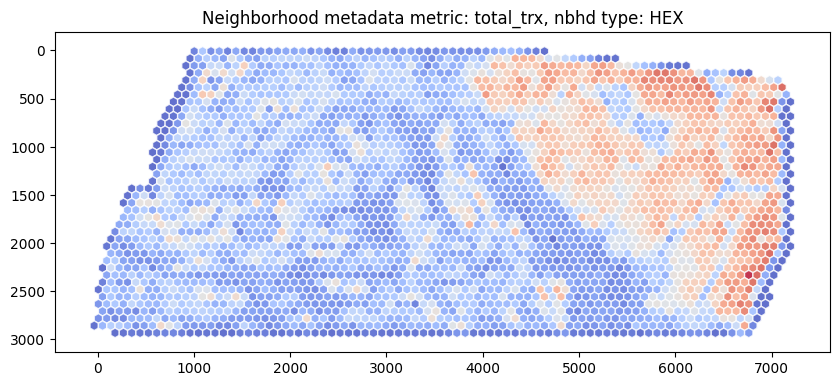

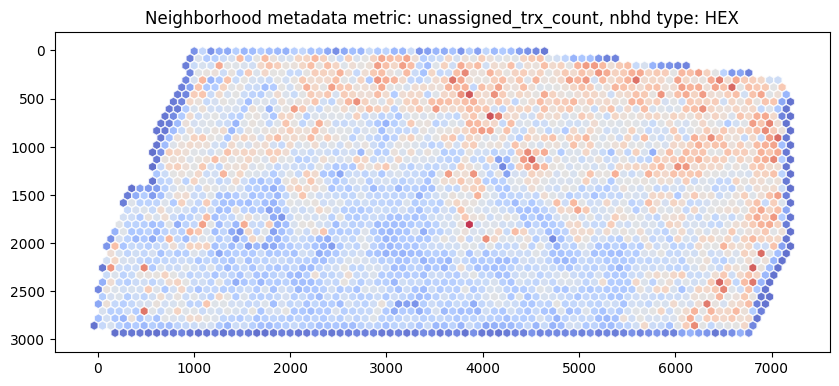

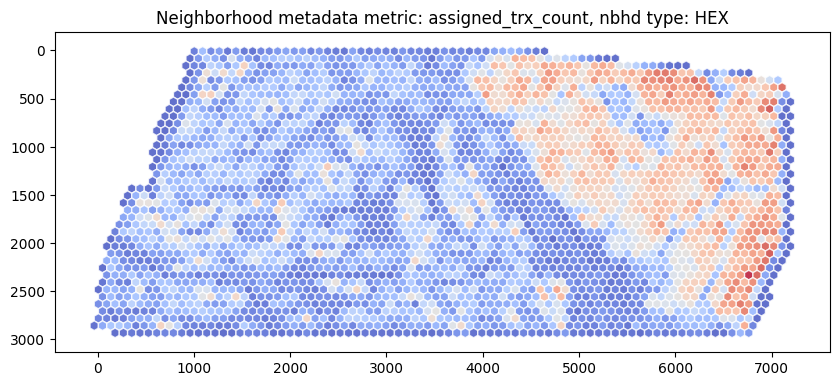

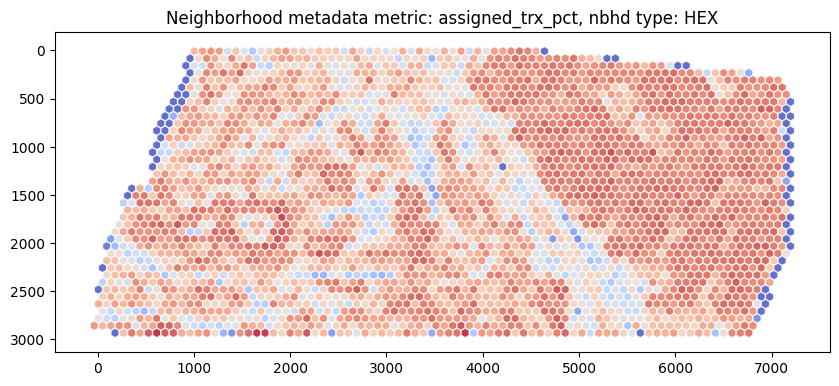

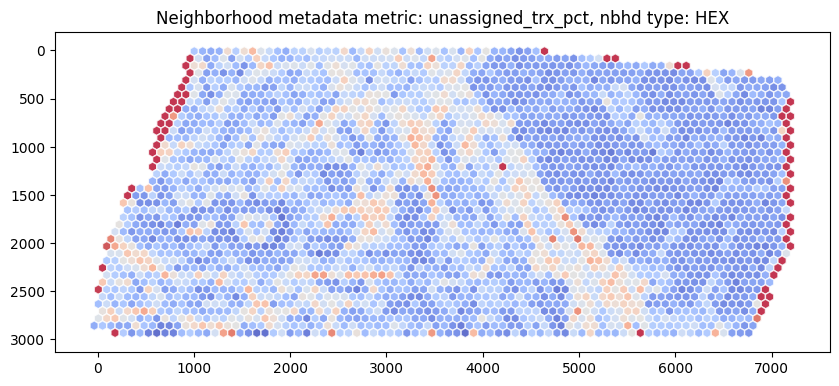

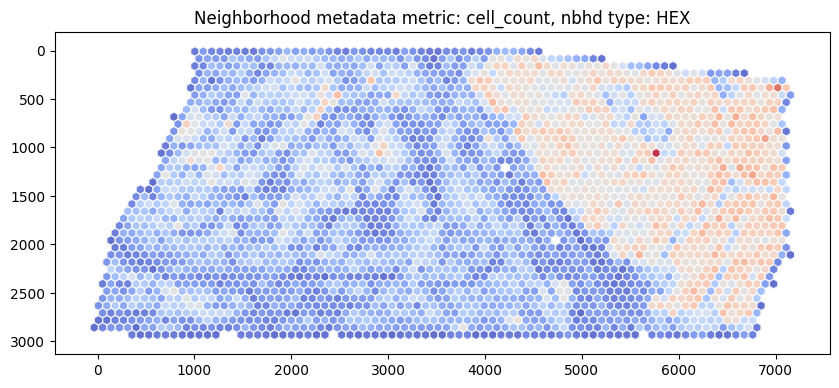

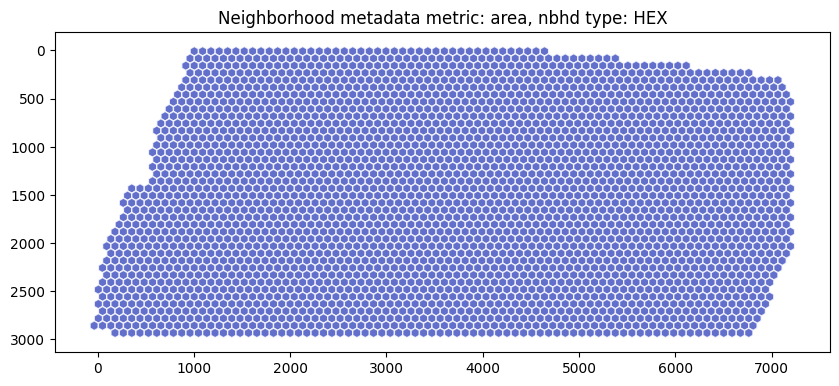

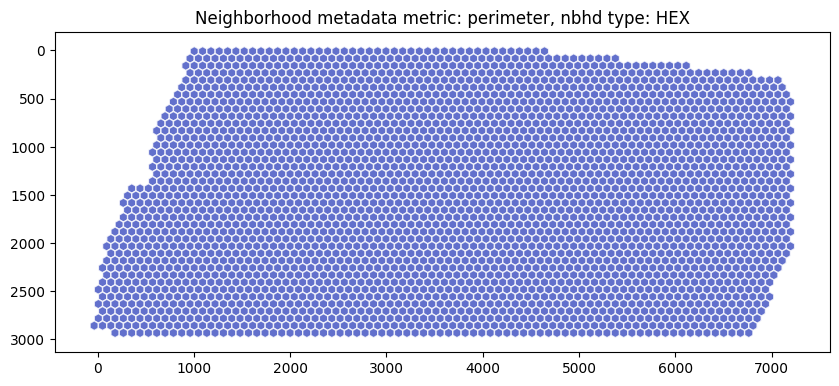

In [9]:
gdf_joined = gdf_nbhd.join(summary, on="name", how="left")

for metric in gdf_joined.select_dtypes(include='number').columns:

    fig, ax = plt.subplots(figsize=(10, 5))                           
    gdf_joined.plot(metric, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'Neighborhood metadata metric: {metric}, nbhd type: {nbhd_type}')
    ax.invert_yaxis()
    plt.show()